# package_DBR

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode

# Load data

In [110]:
nameFile = 'Cleaned_data_Open_loop_experiment_on_MV_2026-03-03-13h34.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)

if 'MV' in nameFile:
    ExpVariable = 'MV'
    tm = data['tm'].values
    MVm = data['MVm'].values
    PVm = data['PVm'].values    
else:    
    ExpVariable = 'DV'
    tm = data['tm'].values
    DVm = data['DVm'].values 
    PVm = data['PVm'].values
     
print(ExpVariable)    

MV


# Parameters optimal FOPDT & SOPDT models

Nous on a un truc qui ressemble a du FO donc c'est possible que certain modele ne fct pas (T1 < 0) ce qu'on peut faire quand on configure le PID avec le FOPDT et SOPDT et voir ce qui change normalement c'est assez robuste pour continuer à fonctionner. 

In [111]:
Kp_FOPDTOPT =  0.37720311160467174
T_FOPDTOPT =  188.30559411020332
theta_FOPDTOPT = 23.189177284051183

Kp_SOPDTOPT = 0.3768941279826313
T1_SOPDTOPT = 187.1409297022807
T2_SOPDTOPT = 10.452990644869
theta_SOPDTOPT = 13.137983829128451 

Ts = 1

# Compare step responses (experiment compared with optimal FOPDT & SOPDT)

(0.0, 809.0)

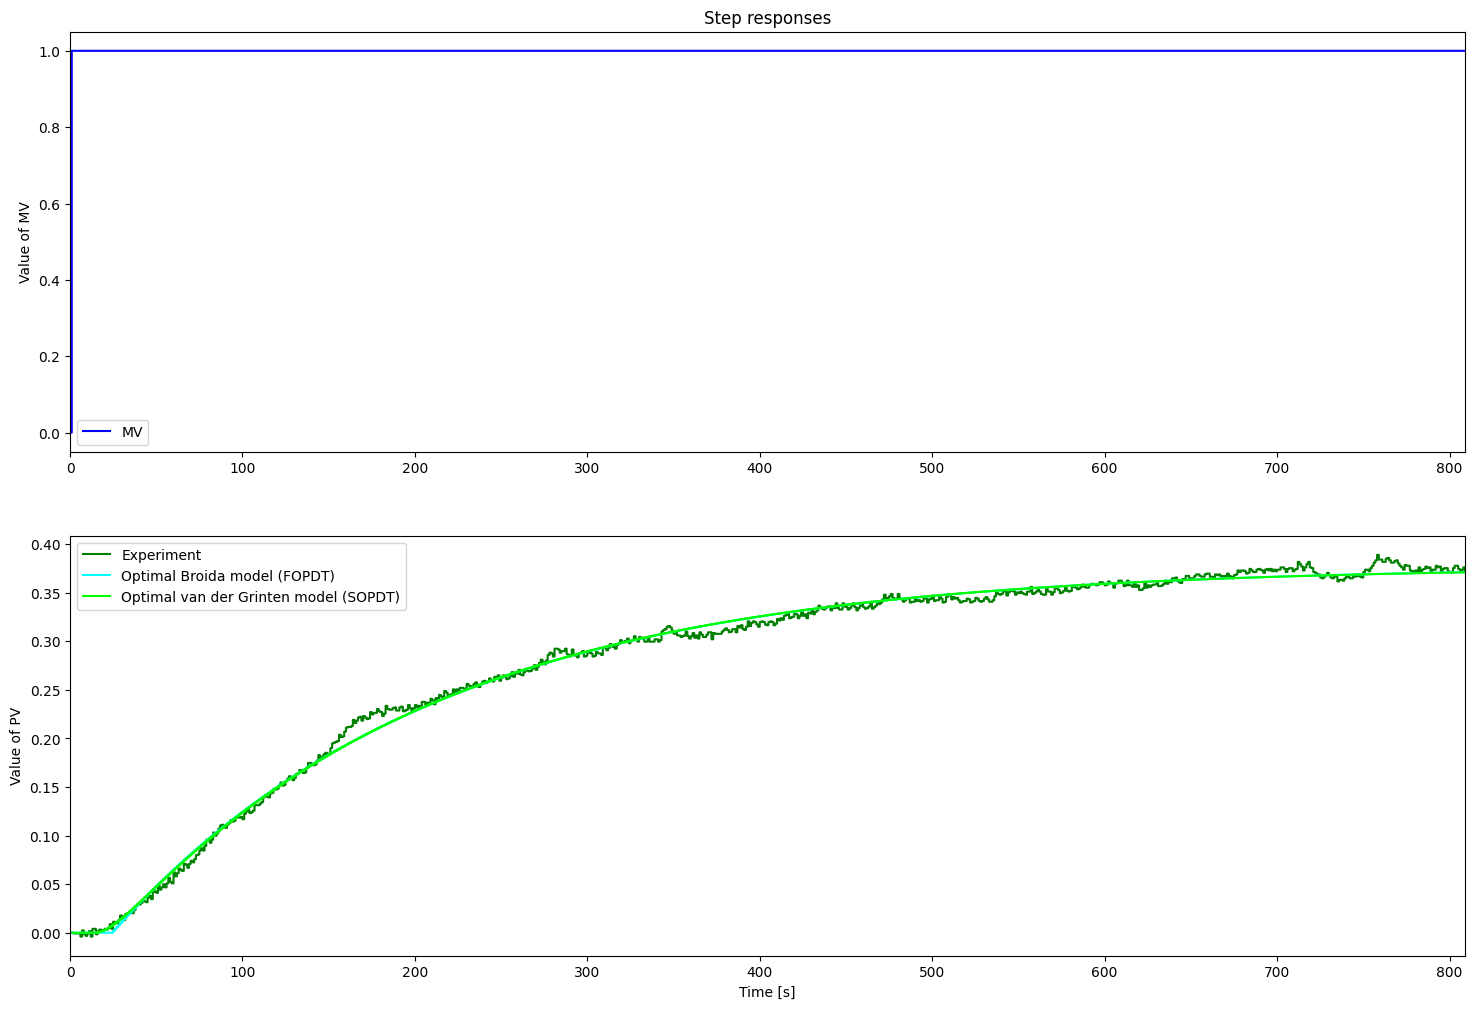

In [112]:
PV_SOPDTOPT = SOPDT(MVm,Kp_SOPDTOPT,T1_SOPDTOPT,T2_SOPDTOPT,theta_SOPDTOPT,Ts)
PV_FOPDTOPT = FOPDT(MVm,Kp_FOPDTOPT,T_FOPDTOPT,theta_FOPDTOPT,Ts)

plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
plt.step(tm,MVm,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.title('Step responses')
plt.legend(loc='best')
plt.xlim([0, np.max(tm)])   

plt.subplot(2,1,2)
plt.step(tm,PVm,'g-',label='Experiment',where='post')
plt.step(tm,PV_FOPDTOPT,'cyan',label='Optimal Broida model (FOPDT)',where='post')
plt.step(tm,PV_SOPDTOPT,'lime',label='Optimal van der Grinten model (SOPDT)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')  
plt.xlim([0, np.max(tm)])

# Compare Bode diagrams (optimal FOPDT & SOPDT)

Text(0, 0.5, 'Phase [°]')

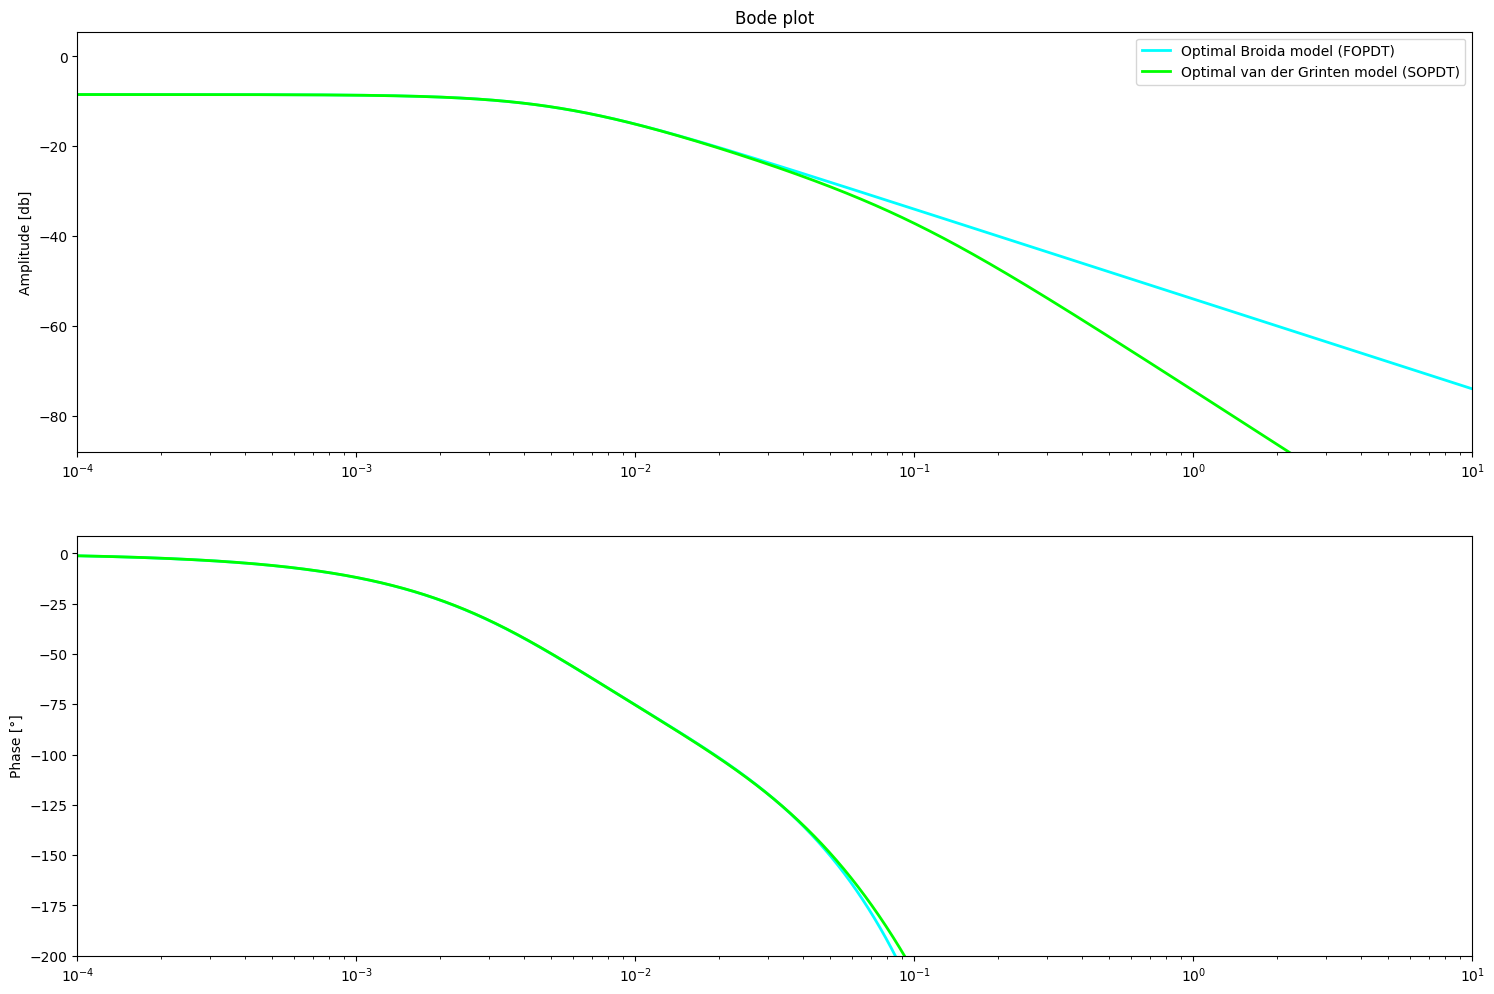

In [113]:


# Frequency response
P_FOPDTOPT = Process({})
P_FOPDTOPT.parameters['Kp'] = Kp_FOPDTOPT
P_FOPDTOPT.parameters['Tlag1'] = T_FOPDTOPT
P_FOPDTOPT.parameters['theta'] = theta_FOPDTOPT

# Frequency response
P_SOPDTOPT = Process({})
P_SOPDTOPT.parameters['Kp'] = Kp_SOPDTOPT
P_SOPDTOPT.parameters['Tlag1'] = T1_SOPDTOPT
P_SOPDTOPT.parameters['Tlag2'] = T2_SOPDTOPT
P_SOPDTOPT.parameters['theta'] = theta_SOPDTOPT

omega = np.logspace(-4, 1, 10000)
Ps_FOPDTOPT = Bode(P_FOPDTOPT,omega,False) # Optimal Broida
Ps_SOPDTOPT = Bode(P_SOPDTOPT,omega,False) # Optimal van der Grinten

plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
gain_min = np.min(20*np.log10(np.abs(Ps_FOPDTOPT)/5))
gain_max = np.max(20*np.log10(np.abs(Ps_FOPDTOPT)*5))
plt.semilogx(omega,20*np.log10(np.abs(Ps_FOPDTOPT)),'cyan',linewidth=2,label='Optimal Broida model (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_SOPDTOPT)),'lime',linewidth=2,label='Optimal van der Grinten model (SOPDT)')
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([gain_min, gain_max])
plt.ylabel('Amplitude [db]')
plt.title('Bode plot')
plt.legend(loc='best')

plt.subplot(2,1,2)
ph_min = np.min((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) - 10
ph_max = np.max((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) + 10
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT)),'cyan',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_SOPDTOPT)),'lime',linewidth=2)
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([np.max([ph_min, -200]), ph_max])
plt.ylabel('Phase [°]')

# Broida 


In [114]:
t1 = 71 #sec
t2 = 89 #sec
K  = 0.377
Tu = 20 #sec
Tg = 251 #sec


### Modéle 1


In [115]:
T_Broida_M1 = Tg
Theta_Broida_M1 = Tu

P_Broida_M1 = Process({})
P_Broida_M1.parameters['Kp'] = K
P_Broida_M1.parameters['Tlag1'] = T_Broida_M1
P_Broida_M1.parameters['theta'] = Theta_Broida_M1


PV_Broida_M1 = FOPDT(MVm,K,T_Broida_M1,Theta_Broida_M1,Ts)

### Modéle 2

In [116]:
T_Broida_M2 = 5.5*(t2-t1)
Theta_Broida_M2 = 2.8*t1 -1.8*t2

P_Broida_M2 = Process({})
P_Broida_M2.parameters['Kp'] = K
P_Broida_M2.parameters['Tlag1'] = T_Broida_M2
P_Broida_M2.parameters['theta'] = Theta_Broida_M2

PV_Broida_M2 = FOPDT(MVm,K,T_Broida_M2,Theta_Broida_M2,Ts)

# Strejc


In [117]:
a = 0
b = 1
T_Strejc =  Tg
Theta_Strejc = Tu

P_Strejc = Process({})
P_Strejc.parameters['Kp'] = K
P_Strejc.parameters['Tlag1'] = T_Strejc
P_Strejc.parameters['theta'] = Theta_Strejc

PV_Strejc = FOPDT(MVm,K,T_Strejc,Theta_Strejc,Ts)


(0.0, 810.0)

<Figure size 2200x2200 with 0 Axes>

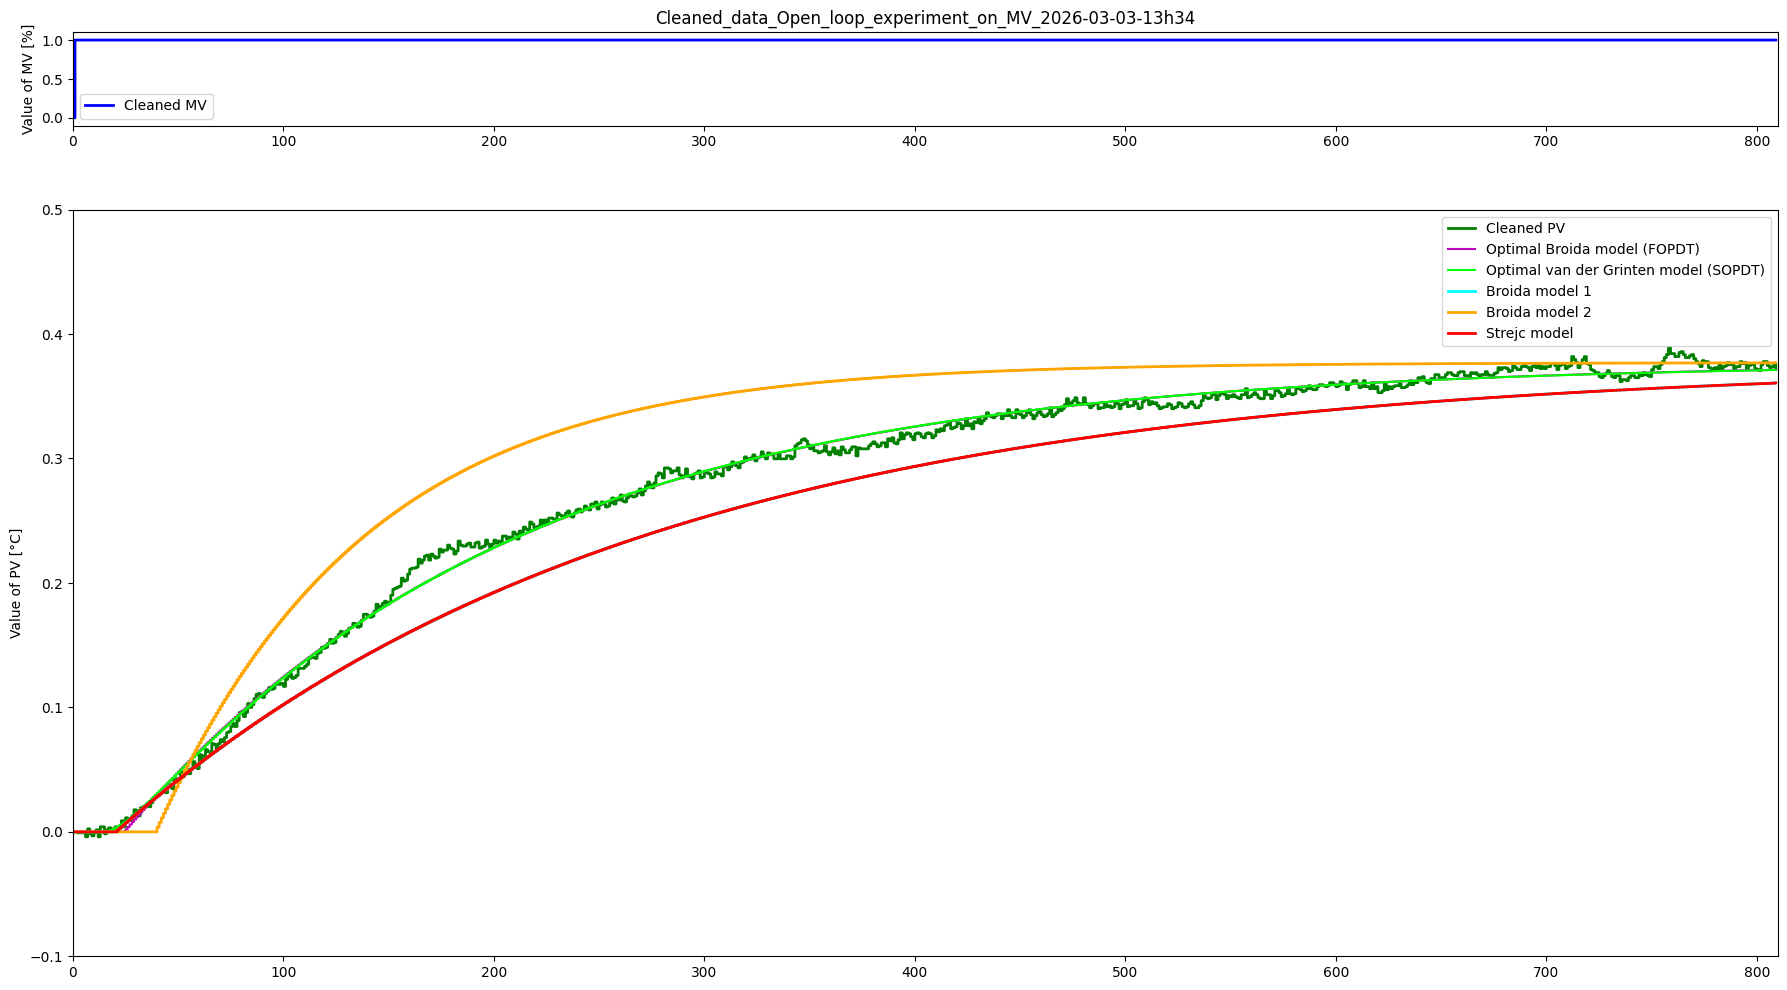

In [118]:
nameFile = 'Cleaned_data_Open_loop_experiment_on_MV_2026-03-03-13h34.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)

if 'MV' in nameFile:
    ExpVariable = 'MV'
    tm = data['tm'].values
    MVm = data['MVm'].values
    PVm = data['PVm'].values    
else:    
    ExpVariable = 'DV'
    tm = data['tm'].values
    DVm = data['DVm'].values 
    PVm = data['PVm'].values


plt.figure(figsize = (22,22))

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [1, 8]})
fig.set_figheight(12)
fig.set_figwidth(22)

if ExpVariable == 'MV':
    l1, = ax1.step([0,1],[0,100],'b-',linewidth=2,label='Cleaned MV',where='post')
    ax1.set_ylabel('Value of MV [%]')
    ax1.set_title(titleName)
    ax1.legend(loc='best')
    l1.set_data(tm,MVm)
    ax1.set_ylim(myRound(np.min(MVm),1)-0.1, myRound(np.max(MVm),1)+0.1)    
else:
    l1, = ax1.step([0,1],[0,100],'b-',linewidth=2,label='Cleaned DV',where='post')
    ax1.set_ylabel('Value of DV [%]')
    ax1.set_title(titleName)
    ax1.legend(loc='best')
    l1.set_data(tm,DVm)
    ax1.set_ylim(myRound(np.min(DVm),1)-0.1, myRound(np.max(DVm),1)+0.1)     

l2, = ax2.step([0,1],[0,100],'g-',linewidth=2,label='Cleaned PV',where='post')
l3, = ax2.step(tm,PV_FOPDTOPT,'-m',label='Optimal Broida model (FOPDT)',where='post')
l4, = ax2.step(tm,PV_SOPDTOPT,'lime',label='Optimal van der Grinten model (SOPDT)',where='post')

l5, = ax2.step([0,1],[0,100],"cyan",linewidth=2,label='Broida model 1',where='post')
l6, = ax2.step([0,1],[0,100],"orange",linewidth=2,label='Broida model 2',where='post')
l7, = ax2.step([0,1],[0,100],"Red",linewidth=2,label='Strejc model',where='post')


ax2.set_ylabel('Value of PV [°C]')
ax2.legend(loc='best')


l2.set_data(tm,PVm)
l5.set_data(tm,PV_Broida_M1)
l6.set_data(tm,PV_Broida_M2)
l7.set_data(tm,PV_Strejc)


ax2.set_ylim(myRound(np.min(PVm),0.1)-0.1, myRound(np.max(PVm),0.1)+0.1)

ax1.set_xlim(0, tm[-1]+1)
ax2.set_xlim(0, tm[-1]+1)

# Bode Dia


Text(0, 0.5, 'Phase [°]')

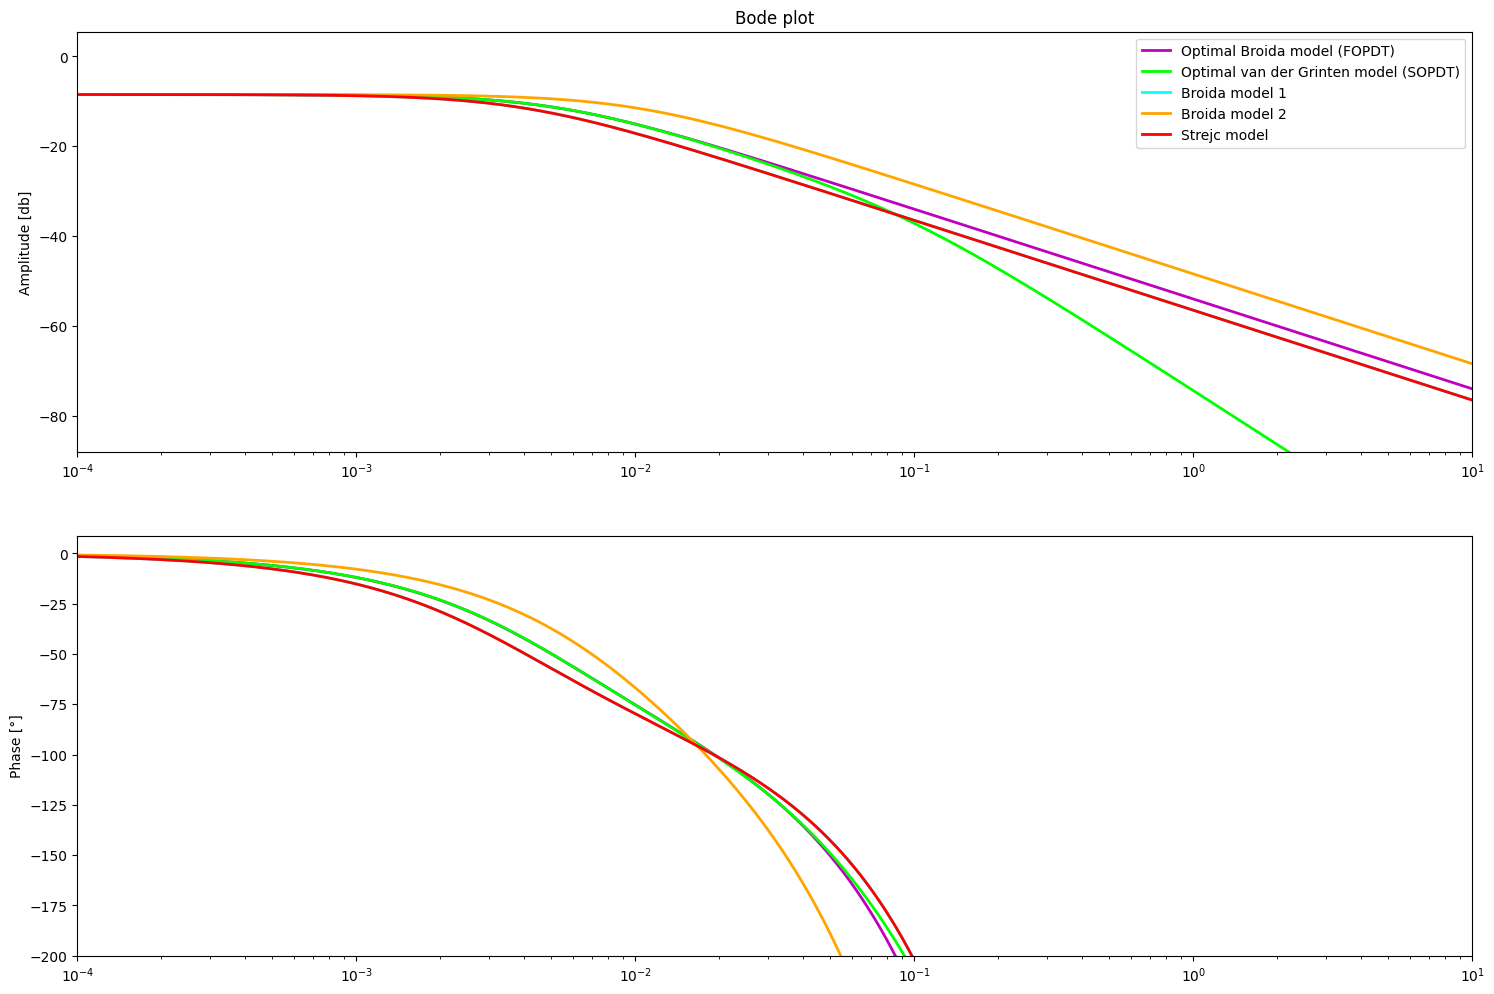

In [122]:
Ps_Broida_M1 = Bode(P_Broida_M1,omega,False) # Broida model 1
Ps_Broida_M2 = Bode(P_Broida_M2,omega,False) # Broida model 2
Ps_Strejc = Bode(P_Strejc,omega,False) # Strejc model




plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
gain_min = np.min(20*np.log10(np.abs(Ps_FOPDTOPT)/5))
gain_max = np.max(20*np.log10(np.abs(Ps_FOPDTOPT)*5))
plt.semilogx(omega,20*np.log10(np.abs(Ps_FOPDTOPT)),'-m',linewidth=2,label='Optimal Broida model (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_SOPDTOPT)),'lime',linewidth=2,label='Optimal van der Grinten model (SOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_Broida_M1)),'cyan',linewidth=2,label='Broida model 1')
plt.semilogx(omega,20*np.log10(np.abs(Ps_Broida_M2)),'orange',linewidth=2,label='Broida model 2')
plt.semilogx(omega,20*np.log10(np.abs(Ps_Strejc)),'-r',linewidth=2,label='Strejc model')

plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([gain_min, gain_max])
plt.ylabel('Amplitude [db]')
plt.title('Bode plot')
plt.legend(loc='best')

plt.subplot(2,1,2)
ph_min = np.min((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) - 10
ph_max = np.max((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) + 10
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT)),'-m',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_SOPDTOPT)),'lime',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_Broida_M1)),'cyan',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_Broida_M2)),'orange',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_Strejc)),'-r',linewidth=2)

plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([np.max([ph_min, -200]), ph_max])
plt.ylabel('Phase [°]')